In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# ※ Quiz : 경주여행과 전주여행에 대해 최빈 단어 시각화와 유사도 분석 시각화

- (1) naver open API를 활용하여 블로그에 "경주여행", "전주여행"을 각각 500건씩 검색하여 백업
    (data/quiz/naver.csv)
     * 백업파일 내용(query, no, title, link, description, total_text(title+ ' ' + description)

- (2) naver.csv에서 total_text를 품사태깅(naver_pos.csv)
     * 파일 내용 : query, no, token, pos

- (3) 명사만 추출(naver_pos_nouns.csv)
     * query, token, pos

- (4) 빈도 분석 백업(naver_pos_nouns_count.csv)
     * token, 경주빈도, 전주빈도, 빈도합     
     
- (5) 빈도 시각화(워드클라우드, Text.plot)
     * 이미지 저장 (data/quiz/)
     
- (6) 단어간 거리 분석(Word2Vec, 연관분석)

# 1. 네이버 open API 활용

In [2]:
# 네이버 검색 API 예제 - 블로그 검색
import os
import pandas as pd
import sys
import urllib.request
from dotenv import load_dotenv
import requests 
import json
load_dotenv() 
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
encText = urllib.parse.quote("경주여행")
url = "https://openapi.naver.com/v1/search/blog?query=" + encText # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
response = urllib.request.urlopen(request)
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8')[:200])
else:
    print("Error Code:" + rescode)

{
	"lastBuildDate":"Fri, 04 Sep 2026 09:28:27 +0900",
	"total":2737279,
	"start":1,
	"display":10,
	"items":[
		{
			"title":"3월의 <b>경주여행<\/b>.",
			"link":"https:\/\/lje77777.tistory.com\/7132",
			"


In [3]:
# 문자 -> dict
import json
from html import unescape # description에 있는 &lt;(특수문자)를 <로 변경
import requests
import pandas as pd
import re #특수문자 @@

In [4]:
# 500개 안되서 start1 100 start 2 100
query ='경주 여행'
start = 1

#2번방법 
#url = f"https://openapi.naver.com/v1/search/blog.json?query={query}&display=100&start={start}"

In [5]:
#1번방법
url = "https://openapi.naver.com/v1/search/blog.json"
params = {
    'query':query,
    'display':100,
    'start':start
         }
headers = {
    "X-Naver-Client-Id":client_id,
    "X-Naver-Client-Secret":client_secret
          }
response = requests.get(url, headers=headers, params=params)
#items = json.loads(response.text)['items']
items = response.json()['items']
items[:2]

[{'title': "I'm a Pedestrian! :: <b>경주여행</b>1",
  'link': 'https://jayson.tistory.com/5180',
  'description': '주초에 1박2일 <b>경주 여행</b>을 했다. 12월초 합창 연주회 연습 일정으로 바쁜 아내만 빠진 3인 가족<b>여행</b>이다. 바쁜 스케줄을 마치고 국내... 직전에 <b>경주</b>로 행로를 바꿀 때 편승했다. 수서역에서 SRT로 신<b>경주</b>역까진... ',
  'bloggername': "I'm a Pedestrian! :: I'm a Pedestrian!",
  'bloggerlink': 'https://jayson.tistory.com/',
  'postdate': '20231129'},
 {'title': '[경북/<b>경주여행</b>]천문 기상 관측대, 첨성대',
  'link': 'https://kwon-blog.tistory.com/1574',
  'description': '*<b>여행</b>일자: 2016년 9월 7일(목) *<b>여행</b>인원: 친구와 함께 첨성대 경북 <b>경주</b>시 인왕동 839-1 전화: 054-779-8741 첨성대 관람료는 무료! ☞ [경북/<b>경주여행</b>]이야기가 있는 <b>경주여행</b> 첨성대에서 바라본 대릉원 야경... ',
  'bloggername': '여행과인생',
  'bloggerlink': 'https://kwon-blog.tistory.com/',
  'postdate': '20170124'}]

In [7]:
# title과 description의 <b></b>없애기, html의 특수문자없애기, 일반특수 없애기]
from html import unescape
import re
item =items[4]
title = item.get('title').replace('<b>',' ').replace('</b>',' ')
title = unescape(title)
title = re.sub(r'[^a-zA-Z0-9가-힣]',' ',title)
description=item['description'].replace('<b>',' ').replace('</b>',' ')
description= unescape(description)
description= re.sub(r'[^a-zA-Z0-9가-힣]',' ',description)
link =item['link']
totaltext = title + ' '+description
print(title, description)

루비의 정원    설연휴  경주 여행   신 경주 역에서 시작하세요  신청은 신 경주 역  여행  센터  광활한 부지에 자리잡은 신 경주 역은 역사 마당도 엄청나게 너른데    연휴  여행 을 계획하고 계신 분은 KTX를 이용한  경주 여행 은 어떠하신지       Copyright 2011  루비  All pictures    


In [ ]:
# re 정규표현식을 이용해서 특수문자 없애기

title = '[여행] ## & ktx 타고 짱 ㅋㅋ ㅠㅠ'
re.sub(r'[^a-zA-Z0-9가-힣]',' ',title)

In [ ]:
# 네이버 API 정보 및 검색 정보
import os
from dotenv import load_dotenv
load_dotenv() 
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')
queries = ['경주 여행', '전주 여행']
max_start =5

In [24]:
# 함수자리!!!
def get_search_item_return(query, start):
    'query와 start로 naver 블로그 검색한 결과로 title link description total_text를 dict list로 반환'
    import requests
    from html import unescape # html 특수문자 제거(ex. &nbsp;)
    import re #일반 특수문자 제거(__.__제거)
    import os
    from dotenv import load_dotenv
    load_dotenv() 
    client_id = os.getenv('CLIENT_ID')
    client_secret = os.getenv('CLIENT_SECRET')
    
    url = "https://openapi.naver.com/v1/search/blog.json"
    params = {
        'query':query,
        'display':100,
        'start':start
             }
    headers = {
        "X-Naver-Client-Id":client_id,
        "X-Naver-Client-Secret":client_secret
              }
    response = requests.get(url, headers=headers, params=params)
    #items = json.loads(response.text)['items']
    items = response.json()['items'] # 100개
    result = [] # items의 title, link, description 등을 dict list로 append
    
    for i, item in enumerate(items):
        no =(start-1)*100 + i + 1 #start가 1일때는 1,2,... 2일때는 101,102
        title = item.get('title').replace('<b>',' ').replace('</b>',' ')
        title = unescape(title)
        title = re.sub(r'[^a-zA-Z0-9가-힣]',' ',title)
        link =item['link']
        description=item['description'].replace('<b>',' ').replace('</b>',' ')
        description= unescape(description)
        description= re.sub(r'[^a-zA-Z0-9가-힣]',' ',description) 
        total_text = title + ' '+description
        #print(query, no, title[:5], description[:5], link,total_text[:5])
        result.append({'query':query, 
                       'no':no,
                       'title':title,
                       'like':link,
                       'description':description,
                       'total_text':total_text})
    return result
get_search_item_return('전주 여행',5)[0]

{'query': '전주 여행',
 'no': 401,
 'title': '  전주여행   퇴근 후 1박 2일  전주여행  2 ',
 'like': 'https://hellosol.tistory.com/109',
 'description': '  전주  1박 2일  여행    객리단길  한옥마을   완주 소양 Day 2 점심   객사 또순이네집   오전에 근처에서 일을보고 점심으로 무엇을 먹을까 고민하다가 숙소와 가까운 객사 맛집을 방문하기로 했다  전주 에 살 때 몇    ',
 'total_text': '  전주여행   퇴근 후 1박 2일  전주여행  2    전주  1박 2일  여행    객리단길  한옥마을   완주 소양 Day 2 점심   객사 또순이네집   오전에 근처에서 일을보고 점심으로 무엇을 먹을까 고민하다가 숙소와 가까운 객사 맛집을 방문하기로 했다  전주 에 살 때 몇    '}

In [30]:
import time
queries = ['경주 여행', '전주 여행']
max_start =5
result_total=[]
for query in queries:
    for start in range(1, max_start+1):
        print(f'{query} 읽어오는 중...{start}/{max_start}')
        get_search_item_return(query, start)
        result_total.extend(get_search_item_return(query, start)) #딕셔너리 리스트에 추가는 extend
        time.sleep(0.5)
        
        
        
    # header와 params와 url 로  request.get(url) -> item   
    # -> title / link / description / total_text
    # ' 검색'  -> 함수 작성

경주 여행 읽어오는 중...1/5
경주 여행 읽어오는 중...2/5
경주 여행 읽어오는 중...3/5
경주 여행 읽어오는 중...4/5
경주 여행 읽어오는 중...5/5
전주 여행 읽어오는 중...1/5
전주 여행 읽어오는 중...2/5
전주 여행 읽어오는 중...3/5
전주 여행 읽어오는 중...4/5
전주 여행 읽어오는 중...5/5


In [31]:
import pandas as pd
df = pd.DataFrame(result_total)
df.shape

(1000, 6)

In [32]:
df.to_csv('data/quiz_naver.csv', encoding='cp949',index=False)

#  2. 품사 태깅 백업
- 파일 내용 : query, no, token, pos
- quiz_naver.csv에서 total_text를 품사태깅(naver_pos.csv)  -> quiz_naver_pos.csv 백업



In [35]:
df=pd.read_csv('data/quiz_naver.csv', encoding='cp949')
df.head(1)

,query,no,title,like,description,total_text
0,경주 여행,1,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사,https://green54.tistory.com/1244,경주여행 때 방문했던 곳들을 다시 한번 남겨보려함 경주여행 경주 밤...,경주여행 동궁과월지 첨성대 야경 연꽃단지 분황사 경주여행 때 방문했던 ...


In [41]:
df_list = df[['query', 'no', 'total_text']].values.tolist()
df_list[::500], len(df_list)

([['경주 여행',
   1,
   ' 경주여행   동궁과월지 첨성대 야경  연꽃단지  분황사  경주여행  때 방문했던 곳들을 다시 한번 남겨보려함     경주여행    경주 밤에가볼만한곳    이웃님들 잘 지내셨나요  지난주 일    blog naver com 예전  여행 사진을 보니  여행 을 떠나고싶어진다 '],
  ['전주 여행',
   1,
   ' 전주여행 코스 전동성당 고풍스러운 멋이 좋아요   전주여행 코스 전동성당 고풍스러운 멋이 좋아요  당일로 다녀왔던  전주  예전에 가서 보지 못한 곳까지 잘 둘러보고 왔습니다  이렇게 좋은 봄날에  여행 만 다니면 얼마나 좋을까 라는    철없는 생각을 해    ']],
 1000)

In [43]:
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab import MeCab
analyzer=MeCab()
postagged_list = [] #품사태깅한 dict list(query, no, token, pos)
stopwords = ['전주', '여행', '경주']
for i, row in enumerate(df_list):
    if i%250==0:
        print(f'총 1000번중 현재 {i}번째 품사태깅중')
    query = row[0]
    no    = row[1]
    total_text = row[2]
    tagged_list = analyzer.pos(total_text)
    for token, tag in tagged_list:
        if token not in stopwords and len(token)>1 : #2글자 이상의 불용어가 아닌 token
            postagged_list.append({'query':query, 
                                   'no':no,
                                   'token':token,
                                   'pos':tag})
    

총 1000번중 현재 0번째 품사태깅중
총 1000번중 현재 250번째 품사태깅중
총 1000번중 현재 500번째 품사태깅중
총 1000번중 현재 750번째 품사태깅중


In [46]:
df_postagged=pd.DataFrame(postagged_list)
# 백업
df_postagged.to_csv('data/quiz_naver_pos.csv',encoding='cp949', index=False)

# 3. 명사만 추출
- MeCab에서의 명사(NNG, NNP, NP)
- query, token, pos 

In [52]:
df_postagged=pd.read_csv('data/quiz_naver_pos.csv', encoding='cp949')
select_pos=['NNG', 'NNP', 'NP']

In [53]:
df_postagged.sample()

,query,no,token,pos
13680,전주 여행,37,시민,NNG


In [55]:
df_nouns=df_postagged.loc[df_postagged['pos'].isin(select_pos),['query','token','pos']]
df_nouns.sample()

,query,token,pos
7175,경주 여행,휴게소,NNG


In [107]:
df_nouns.to_csv('data/quiz_naver_pos_noun.csv',encoding='cp949', index=False)

# 4. 빈도 분석 
- token, 경주빈도, 전주빈도, 빈도합, 경주비율, 전주비율

In [59]:
df_nouns.groupby(['query'],as_index=False)['pos'].count()

,query,pos
0,경주 여행,8015
1,전주 여행,8965


In [67]:
df_token_grp = df_nouns.groupby(['query','token'],as_index=False).count()
df_token_grp.rename(columns={'pos':'count'},inplace=True)
df_token_grp

,query,token,count
0,경주 여행,가격,12
1,경주 여행,가능,10
2,경주 여행,가보세요,5
3,경주 여행,가본,5
4,경주 여행,가요,2
...,...,...,...
1518,전주 여행,휴가,5
1519,전주 여행,휴강,1
1520,전주 여행,휴게소,5
1521,전주 여행,흔적,5


In [71]:
df_gj=df_token_grp.loc[df_token_grp['query']=='경주 여행',['token','count']]
df_jj=df_token_grp.loc[df_token_grp['query']=='전주 여행',['token','count']]
df_gj.shape, df_jj.shape

((700, 2), (823, 2))

In [73]:
df_gj.head(5)

,token,count
0,가격,12
1,가능,10
2,가보세요,5
3,가본,5
4,가요,2


In [74]:
df_jj.head(5)

,token,count
700,가게,18
701,가격,10
702,가능,5
703,가마솥,5
704,가세,5


In [97]:
# 두 데이터 프레임 병합
df_mrg=pd.merge(df_gj,df_jj,on='token', how='outer')
df_mrg.fillna(0,inplace=True)
df_mrg=df_mrg.rename(columns={'count_x':'경주빈도','count_y':'전주빈도'})

In [100]:
df_mrg['경주빈도']=df_mrg['경주빈도'].astype('int')
df_mrg['전주빈도']=df_mrg['전주빈도'].astype('int')
df_mrg['빈도합']=df_mrg['경주빈도']+df_mrg['전주빈도']
df_mrg=df_mrg.sort_values(by='빈도합',ascending=False)
df_mrg.head()

,token,경주빈도,전주빈도,빈도합
1287,한옥마을,0,323,323
482,일상,295,0,295
35,고고학,291,0,291
190,맛집,40,155,195
388,알라딘,137,54,191


In [104]:
df_mrg['경주비율']=round(df_mrg['경주빈도']/df_mrg['빈도합']*100,1)
df_mrg['전주비율']=round(df_mrg['전주빈도']/df_mrg['빈도합']*100,1)
df_mrg

,token,경주빈도,전주빈도,빈도합,경주비율,전주비율
1287,한옥마을,0,323,323,0.0,100.0
482,일상,295,0,295,100.0,0.0
35,고고학,291,0,291,100.0,0.0
190,맛집,40,155,195,20.5,79.5
388,알라딘,137,54,191,71.7,28.3
...,...,...,...,...,...,...
1182,주공,0,1,1,0.0,100.0
669,햇빛,1,0,1,100.0,0.0
1164,정감,0,1,1,0.0,100.0
920,번지,0,1,1,0.0,100.0


# 5. 빈도 시각화(워드클라우드, Text)

In [151]:
df_nouns=pd.read_csv('data/quiz_naver_pos_noun.csv',encoding='cp949')
df_nouns.shape

(16980, 3)

In [152]:
df_nouns.head(3)

,query,token,pos
0,경주 여행,동궁,NNG
1,경주 여행,월지,NNG
2,경주 여행,첨성대,NNG


In [185]:
# 경주 명사들만 워드클라우드
df_nouns_gj_list=df_nouns.loc[df_nouns['query']=='경주 여행']['token'].tolist()
gj_nouns=' '.join(df_nouns_gj_list)

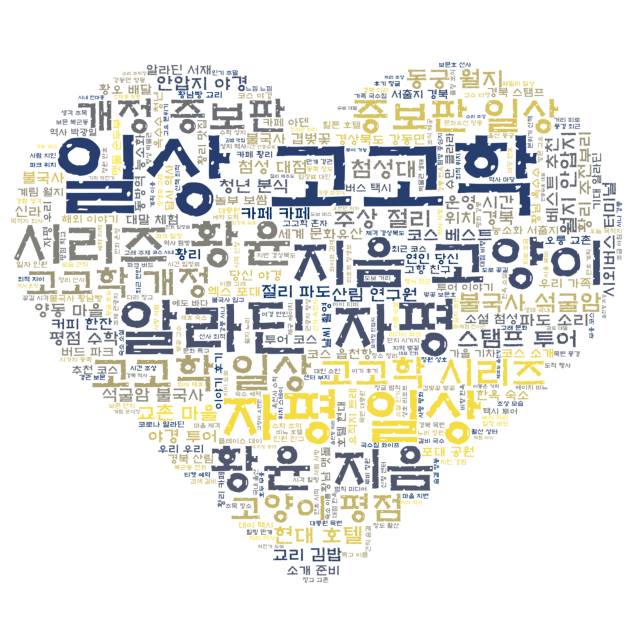

In [164]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
img = Image.open('data/heart.jpg')
mask = np.array(img)
wordcloud=WordCloud(
                font_path='C:/Windows/Fonts/H2MKPB.TTF',
                background_color='white',
                max_words=300,
                mask=mask,
                colormap='cividis')
wordcloud.generate(gj_nouns)
plt.figure(figsize=(12,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [186]:
# 전주 명사들만 워드클라우드
df_nouns_jj_list=df_nouns.loc[df_nouns['query']=='전주 여행']['token'].tolist()
jj_nouns=' '.join(df_nouns_jj_list)

In [181]:
'마을' in df_nouns_list

True

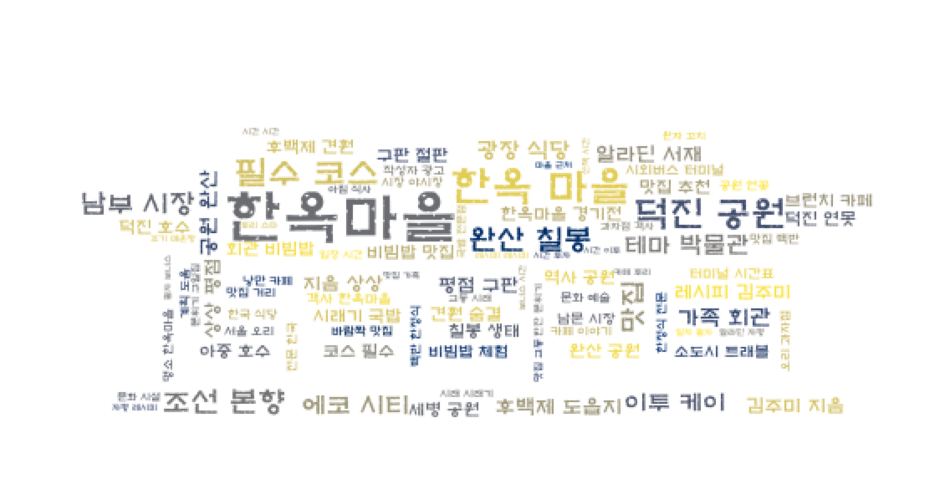

In [167]:
img = Image.open('data/korea-house-black-fill.png')
mask2 = np.array(img)
wordcloud=WordCloud(
                font_path='C:/Windows/Fonts/H2MKPB.TTF',
                background_color='white',
                max_words=300,
                mask=mask2,
                colormap='cividis')
wordcloud.generate(jj_nouns)
plt.figure(figsize=(12,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

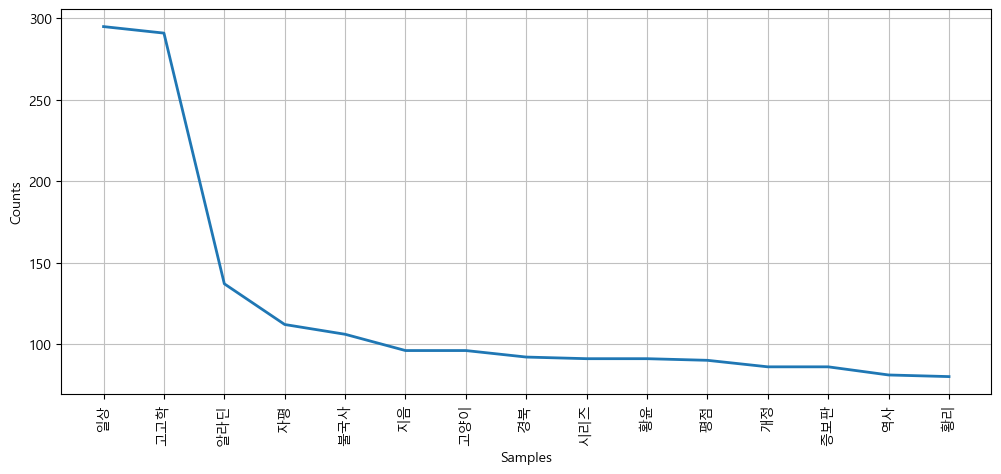

<Axes: xlabel='Samples', ylabel='Counts'>

In [187]:
# 경주 명사들 Text plot
from nltk import Text
plt.rcParams['font.family']='Malgun Gothic' 
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize']=[12,5]
data_text= Text(df_nouns_gj_list)
data_text.plot(15)

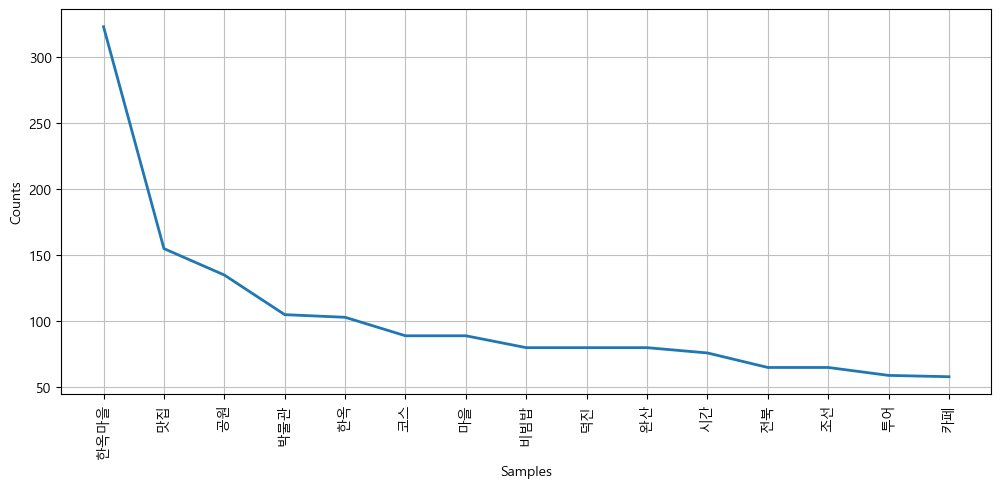

<Axes: xlabel='Samples', ylabel='Counts'>

In [188]:
# 전주 명사들 Text plot
plt.rcParams['figure.figsize']=[12,5]
data_text= Text(df_nouns_jj_list)
data_text.plot(15)

# 6. 워드 임베딩
- Word2Vec

In [195]:
from gensim.models import Word2Vec
model =Word2Vec([df_nouns_gj_list],window=15,min_count=2,workers=-1,sg=1)
model.wv.most_similar('시리즈',topn=10)

[('자전거', 0.37102869153022766),
 ('반월', 0.3137136697769165),
 ('황룡사', 0.2849687337875366),
 ('골목길', 0.2701706886291504),
 ('해변', 0.26691991090774536),
 ('가본', 0.2645510733127594),
 ('단풍', 0.25067126750946045),
 ('순두부', 0.2474413961172104),
 ('스토리', 0.2409459501504898),
 ('촬영', 0.23578433692455292)]

In [196]:
model =Word2Vec([df_nouns_jj_list],window=15,min_count=2,workers=-1,sg=1)
model.wv.most_similar('한옥',topn=10)

[('누구', 0.32869330048561096),
 ('소도시', 0.26987090706825256),
 ('하우스', 0.26623496413230896),
 ('투어', 0.2529045641422272),
 ('사람', 0.24194024503231049),
 ('이름', 0.22407135367393494),
 ('데프콘', 0.21756117045879364),
 ('개관', 0.2168613225221634),
 ('동고', 0.21634499728679657),
 ('대회', 0.2142491638660431)]